<a href="https://colab.research.google.com/github/lukazsw/Machine-Learning-2025L/blob/main/lw430257_homework04.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Praca Domowa: LAB04_PENALIZED_REGRESSION

# Autor: Łukasz Wysocki

Celem tej pracy jest odpowiedź na pytanie:

**Jak zmiana parametru regularyzacji $\lambda$ w regresji Ridge i Lasso wpływa na kompromis między bias i variance?**

W pracy sprawdzę, jak wzrost siły regularyzacji wpływa na obciążenie modelu, zmienność predykcji oraz końcowy błąd predykcji. W tym celu wykorzystam syntetyczny zbiór danych wygenerowany z modelu liniowego o znanych współczynnikach, w którym większość parametrów będzie równa 0, a tylko kilka będzie niezerowych.

W pracy wykonam następujące kroki:

- zdefiniuję prawdziwy model liniowy z niewielką liczbą niezerowych współczynników,
- wygeneruję dane treningowe i duży zbiór testowy z ustalonego rozkładu,
- wielokrotnie wytrenuję modele Ridge i Lasso dla różnych wartości parametru $\lambda$,
- oszacuję bias, variance oraz MSE na zbiorze testowym,
- przedstawię wyniki na wykresach i porównam zachowanie obu metod.

W szczególności przeanalizuję:

- jak zmienia się $Bias^2$ wraz ze wzrostem $\lambda$,
- jak zmienia się $Variance$ wraz ze wzrostem $\lambda$,
- czy MSE przyjmuje kształt litery U,
- czy istnieje optymalny poziom regularyzacji minimalizujący MSE.

Na końcu odpowiem również na pytania dotyczące dekompozycji MSE na składnik bias, variance oraz irreducible error, a także pokażę, w jakich warunkach Ridge i Lasso mogą dawać lepsze wyniki.

## Dekompozycja MSE

Dla nowego punktu testowego $x_0$ oczekiwany błąd predykcji można zapisać jako:
$$
\mathbb{E}\left[\left(y_0 - \hat f(x_0)\right)^2\right]
=
\operatorname{Bias}(\hat f(x_0))^2
+
\operatorname{Variance}(\hat f(x_0))
+
\operatorname{Var}(\varepsilon),
$$
gdzie
$$
\operatorname{Bias}(\hat f(x_0)) = \mathbb{E}[\hat f(x_0)] - f(x_0).
$$

Oznacza to, że całkowity błąd predykcji składa się z trzech części:
- $Bias^2$, czyli błędu wynikającego z uproszczenia modelu,
- $Variance$, czyli wrażliwości modelu na zmianę danych treningowych,
- błędu nieusuwalnego, czyli $\operatorname{Var}(\varepsilon)$.

W dalszej części pracy sprawdzę, jak zmiana parametru regularyzacji $\lambda$ wpływa na każdy z tych składników w regresji Ridge i Lasso.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import Ridge, Lasso
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.metrics import mean_squared_error

In [2]:
rng = np.random.default_rng(42)

# Simulation setup
n_train = 100
n_test = 5000
n_features = 50
n_repetitions = 100
sigma = 1.0

# True sparse coefficient vector
beta_0 = 2.0
beta_true = np.zeros(n_features)
beta_true[:5] = [3.0, -2.5, 1.5, 2.0, -1.0]

# Grid of regularization strengths
lambdas = np.geomspace(1e-3, 1e2, 25)

In [3]:
def true_signal(X, beta_0, beta_true):
    return beta_0 + X @ beta_true


def generate_data(n_samples, n_features, beta_0, beta_true, sigma, rng):
    X = rng.normal(loc=0.0, scale=1.0, size=(n_samples, n_features))
    f_X = true_signal(X, beta_0, beta_true)
    epsilon = rng.normal(loc=0.0, scale=sigma, size=n_samples)
    y = f_X + epsilon
    return X, y, f_X

In [4]:
X_test, y_test, f_test = generate_data(
    n_samples=n_test,
    n_features=n_features,
    beta_0=beta_0,
    beta_true=beta_true,
    sigma=sigma,
    rng=rng
)

## Estymacja bias, variance i MSE

W celu zbadania kompromisu między bias i variance będę korzystać z jednego dużego, ustalonego zbioru testowego oraz wielu niezależnie losowanych zbiorów treningowych.

Dla każdej wartości parametru $\lambda$:
- wielokrotnie losuję nowy zbiór treningowy,
- uczę model Ridge lub Lasso,
- wyznaczam predykcje na tych samych punktach testowych.

Następnie dla każdego punktu testowego $x$ estymuję:
$$
\operatorname{Bias}(\hat f(x)) = \mathbb{E}[\hat f(x)] - f(x),
$$
$$
\operatorname{Variance}(\hat f(x)) = \mathbb{E}\left[(\hat f(x) - \mathbb{E}[\hat f(x)])^2\right],
$$
oraz
$$
\operatorname{MSE}(x) = \mathbb{E}\left[(y - \hat f(x))^2\right].
$$

W praktyce wartości te przybliżam przez uśrednianie po wielu wytrenowanych modelach, a następnie dodatkowo uśredniam po całym zbiorze testowym.

Korzystam z prawdziwej funkcji $f(x)$ przy obliczaniu bias, a nie z obserwacji $y = f(x) + \varepsilon$, aby nie mieszać biasu z irreducible error.

In [5]:
def evaluate_penalized_model(model_name, lambdas, n_repetitions):
    results = {
        "lambda": [],
        "bias_squared": [],
        "variance": [],
        "mse": [],
        "irreducible_error": []
    }

    for lam in lambdas:
        test_predictions = np.zeros((n_repetitions, n_test))

        for rep in range(n_repetitions):
            X_train, y_train, _ = generate_data(
                n_samples=n_train,
                n_features=n_features,
                beta_0=beta_0,
                beta_true=beta_true,
                sigma=sigma,
                rng=rng
            )

            if model_name == "ridge":
                model = make_pipeline(
                    StandardScaler(),
                    Ridge(alpha=lam)
                )
            elif model_name == "lasso":
                model = make_pipeline(
                    StandardScaler(),
                    Lasso(alpha=lam, max_iter=20000)
                )
            else:
                raise ValueError("model_name must be either 'ridge' or 'lasso'")

            model.fit(X_train, y_train)
            test_predictions[rep] = model.predict(X_test)

        mean_prediction = test_predictions.mean(axis=0)

        bias_squared = np.mean((mean_prediction - f_test) ** 2)
        variance = np.mean(np.var(test_predictions, axis=0))
        mse = np.mean((test_predictions - y_test) ** 2)
        irreducible_error = sigma ** 2

        results["lambda"].append(lam)
        results["bias_squared"].append(bias_squared)
        results["variance"].append(variance)
        results["mse"].append(mse)
        results["irreducible_error"].append(irreducible_error)

    return pd.DataFrame(results)

In [6]:
ridge_results = evaluate_penalized_model(
    model_name="ridge",
    lambdas=lambdas,
    n_repetitions=n_repetitions
)

lasso_results = evaluate_penalized_model(
    model_name="lasso",
    lambdas=lambdas,
    n_repetitions=n_repetitions
)

In [8]:
ridge_results.head()

,lambda,bias_squared,variance,mse,irreducible_error
0,0.001000,0.015760,1.049300,2.102870,1.0
1,0.001616,0.010376,1.031618,2.082332,1.0
2,0.002610,0.012860,1.065779,2.115124,1.0
3,0.004217,0.010192,1.005217,2.056023,1.0
4,0.006813,0.012734,1.060407,2.110149,1.0


In [9]:
lasso_results.head()

,lambda,bias_squared,variance,mse,irreducible_error
0,0.001000,0.010432,0.989220,2.034541,1.0
1,0.001616,0.008617,0.950253,1.997441,1.0
2,0.002610,0.007586,0.930765,1.974689,1.0
3,0.004217,0.005335,0.815389,1.861294,1.0
4,0.006813,0.008957,0.786438,1.835869,1.0


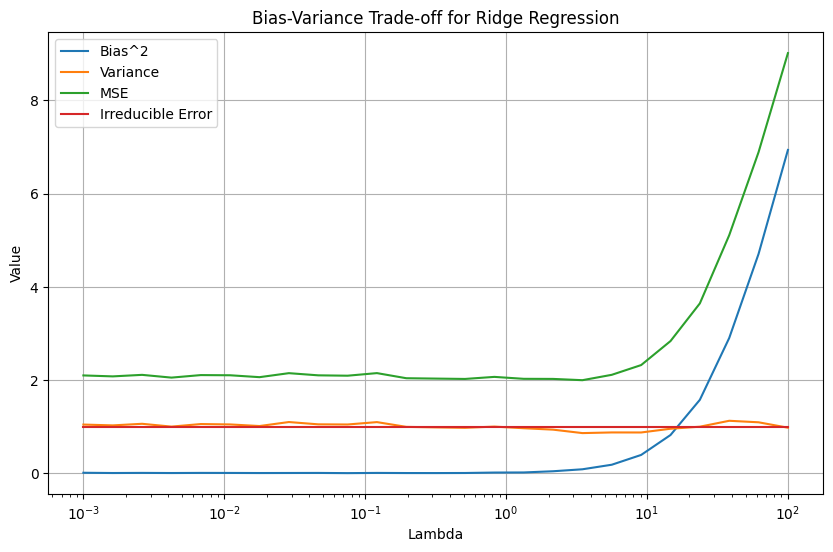

In [10]:
plt.figure(figsize=(10, 6))
plt.plot(ridge_results["lambda"], ridge_results["bias_squared"], label="Bias^2")
plt.plot(ridge_results["lambda"], ridge_results["variance"], label="Variance")
plt.plot(ridge_results["lambda"], ridge_results["mse"], label="MSE")
plt.plot(ridge_results["lambda"], ridge_results["irreducible_error"], label="Irreducible Error")

plt.xscale("log")
plt.xlabel("Lambda")
plt.ylabel("Value")
plt.title("Bias-Variance Trade-off for Ridge Regression")
plt.legend()
plt.grid(True)
plt.show()

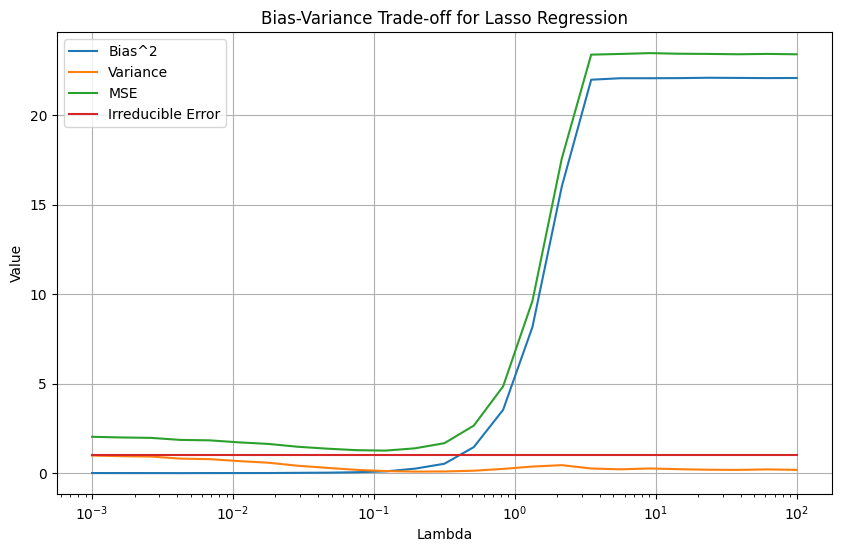

In [11]:
plt.figure(figsize=(10, 6))
plt.plot(lasso_results["lambda"], lasso_results["bias_squared"], label="Bias^2")
plt.plot(lasso_results["lambda"], lasso_results["variance"], label="Variance")
plt.plot(lasso_results["lambda"], lasso_results["mse"], label="MSE")
plt.plot(lasso_results["lambda"], lasso_results["irreducible_error"], label="Irreducible Error")

plt.xscale("log")
plt.xlabel("Lambda")
plt.ylabel("Value")
plt.title("Bias-Variance Trade-off for Lasso Regression")
plt.legend()
plt.grid(True)
plt.show()

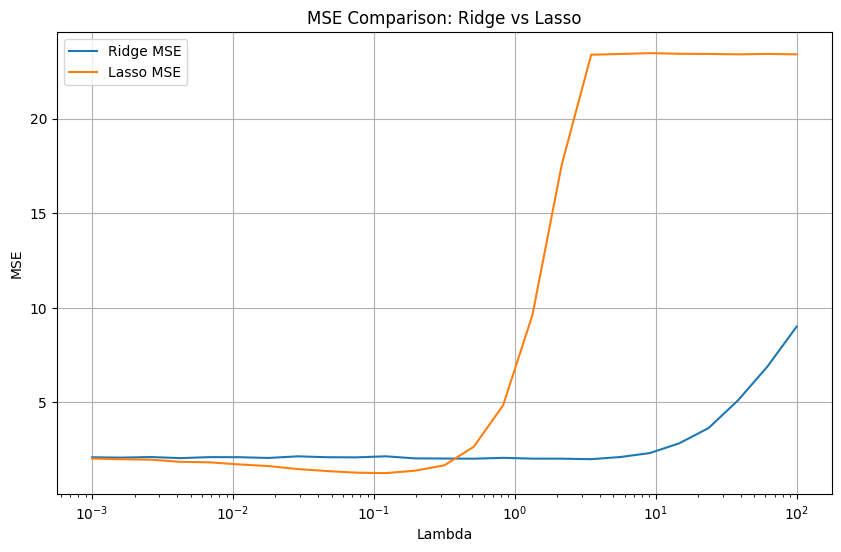

In [12]:
plt.figure(figsize=(10, 6))
plt.plot(ridge_results["lambda"], ridge_results["mse"], label="Ridge MSE")
plt.plot(lasso_results["lambda"], lasso_results["mse"], label="Lasso MSE")

plt.xscale("log")
plt.xlabel("Lambda")
plt.ylabel("MSE")
plt.title("MSE Comparison: Ridge vs Lasso")
plt.legend()
plt.grid(True)
plt.show()

In [13]:
best_ridge = ridge_results.loc[ridge_results["mse"].idxmin()]
best_lasso = lasso_results.loc[lasso_results["mse"].idxmin()]

print("Best Ridge:")
print(best_ridge)
print()

print("Best Lasso:")
print(best_lasso)

Best Ridge:
lambda               3.480701
bias_squared         0.090441
variance             0.866278
mse                  2.000774
irreducible_error    1.000000
Name: 17, dtype: float64

Best Lasso:
lambda               0.121153
bias_squared         0.103039
variance             0.117647
mse                  1.263787
irreducible_error    1.000000
Name: 10, dtype: float64


## Czy istnieje optymalny poziom regularyzacji?

Wyniki pokazują, że dla obu metod istnieje taka wartość parametru $\lambda$, dla której MSE jest minimalne. Oznacza to, że regularizacja może prowadzić do optymalnego kompromisu między bias i variance.

W modelu Ridge minimalne MSE uzyskałem dla:
$$
\lambda \approx 3.48
$$

W modelu Lasso minimalne MSE uzyskałem dla:
$$
\lambda \approx 0.12
$$

Taki punkt istnieje, ponieważ przy bardzo małych wartościach $\lambda$ model jest bardziej elastyczny, więc ma niski bias, ale większą wariancję. Z kolei przy bardzo dużych wartościach $\lambda$ model staje się zbyt mocno ograniczony, przez co wariancja maleje, ale rośnie bias. Dla pewnego pośredniego poziomu regularyzacji suma tych efektów jest najmniejsza, dlatego MSE osiąga minimum.

W badanym eksperymencie Lasso osiągnęło niższe minimalne MSE niż Ridge, co sugeruje, że przy zadanej strukturze danych lepiej wykorzystuje fakt, że prawdziwy model jest rzadki, czyli zawiera tylko kilka niezerowych współczynników.

## Wnioski

Na podstawie przeprowadzonego eksperymentu widać, że wzrost parametru $\lambda$ wpływa na Ridge i Lasso zgodnie z klasycznym kompromisem bias-variance.

W obu metodach wraz ze wzrostem $\lambda$:
- rośnie bias, ponieważ współczynniki są coraz silniej ograniczane,
- maleje variance, ponieważ model staje się mniej wrażliwy na losowe zmiany w zbiorze treningowym,
- irreducible error pozostaje stały i dodatni, ponieważ zależy wyłącznie od wariancji szumu,
- MSE początkowo może maleć, ale dla zbyt dużej regularyzacji zaczyna rosnąć.

Otrzymane wykresy pokazują, że MSE rzeczywiście ma minimum dla pośrednich wartości $\lambda$, co potwierdza istnienie optymalnego punktu kompromisu między bias i variance.

Ridge i Lasso różnią się jednak sposobem działania. Ridge kurczy współczynniki w stronę zera w sposób ciągły, ale zwykle ich nie zeruje. Dzięki temu dobrze radzi sobie wtedy, gdy wiele zmiennych wnosi niewielką informację lub gdy predyktory są silnie skorelowane. Lasso działa bardziej agresywnie, ponieważ może dokładnie wyzerować część współczynników, a więc jednocześnie wykonuje regularyzację i selekcję zmiennych.

W tym eksperymencie Lasso osiągnęło niższe minimalne MSE niż Ridge. Jest to zgodne z konstrukcją danych, ponieważ prawdziwy model był rzadki: tylko kilka współczynników było niezerowych, a większość predyktorów nie miała wpływu na odpowiedź. W takiej sytuacji Lasso może lepiej odtworzyć strukturę modelu. Ridge może być natomiast korzystniejszy wtedy, gdy sygnał jest rozproszony pomiędzy wiele zmiennych lub gdy szczególnie ważna jest stabilność przy współliniowości predyktorów.

In [14]:
ridge_results["mse_minus_bias_var"] = (
    ridge_results["mse"] - ridge_results["bias_squared"] - ridge_results["variance"]
)

lasso_results["mse_minus_bias_var"] = (
    lasso_results["mse"] - lasso_results["bias_squared"] - lasso_results["variance"]
)

print("Ridge:")
print(ridge_results[["lambda", "mse_minus_bias_var"]].head())
print()

print("Lasso:")
print(lasso_results[["lambda", "mse_minus_bias_var"]].head())

Ridge:
     lambda  mse_minus_bias_var
0  0.001000            1.037809
1  0.001616            1.040338
2  0.002610            1.036485
3  0.004217            1.040613
4  0.006813            1.037008

Lasso:
     lambda  mse_minus_bias_var
0  0.001000            1.034889
1  0.001616            1.038571
2  0.002610            1.036338
3  0.004217            1.040569
4  0.006813            1.040473


## Podsumowanie

Dodatkowe obliczenia pokazują, że różnica
$$
MSE - Bias^2 - Variance
$$
jest w przybliżeniu równa
$$
\sigma^2 = 1,
$$
co potwierdza poprawność dekompozycji MSE oraz to, że bias był liczony względem prawdziwej funkcji $f(X)$, a nie względem zaszumionych obserwacji $y$.

W przeprowadzonym eksperymencie Lasso osiągnęło niższe minimalne MSE niż Ridge, co jest zgodne z konstrukcją danych, ponieważ prawdziwy model był rzadki i zawierał tylko kilka niezerowych współczynników. Warto jednak pamiętać, że wynik ten zależy od charakteru danych. Przy silnej współliniowości predyktorów lub gdy sygnał jest rozłożony na większą liczbę zmiennych, Ridge może wypadać lepiej dzięki większej stabilności estymacji.